In [3]:
# 讀入習慣的資料科學套件
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [4]:
#讀入資料，這邊要注意檔案的儲存路徑！
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv') 
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# 查看數據的變數、總數、缺失數據、變數measurement(維度)
def data_overview():
    print("Rows :  " , df.shape[0])
    print("Columns:  " , df.shape[1] )
    print('Missing Value number : ' , df.isnull().sum().values.sum()) #isnull.sum()會對每條series做sum up ，所以我們還要取出value做一次sum up .
    print('\nUnique values' , df.nunique())
data_overview()

Rows :   7043
Columns:   21
Missing Value number :  0

Unique values customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64


In [6]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [7]:
df['Churn'].value_counts(normalize=True).round(3) #normalize=True 會將數據轉換成百分比，

Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64

In [8]:
# 作圖發現有極端值的嫌疑
# sns.histplot(df.tenure)

In [9]:
df["Churn"][df["Churn"]=="Yes"].groupby(by=df["gender"]).count()

gender
Female    939
Male      930
Name: Churn, dtype: int64

##Data Manipulation

In [10]:
df = df.drop(['customerID'], axis = 1)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
# 替代掉空白值當作null
df['TotalCharges'] = df.TotalCharges.replace(' ' , np.nan)
print(df.TotalCharges.isnull().sum())
# 查看都是哪些類型的數據缺失
df[df.TotalCharges.isnull()]
#查看原始數據，我們知道二分數據為Yes/No，我們想要把他們編碼，這樣方便之後的modeling
#df = df.replace({'Yes':1 , 'No' :0})

#再轉換一次型態
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

#轉換二項data-churn的型態，將Yes轉換為1，No轉換為0
#df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

#繼續清理數據，將No internet service轉換為No
no_internet_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection',
                     'TechSupport','StreamingTV','StreamingMovies']
for c in no_internet_cols:
    df[c] = df[c].replace('No internet service', 'No')
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

print('缺失數據變為：')
print(df.isnull().sum())




11
缺失數據變為：
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [12]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[numerical_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


##Data Visualization

In [16]:
# 先導入相關套件
import plotly.offline as py
py.init_notebook_mode(connected=True) #為了能在本地端調用
import plotly.graph_objs as go
import plotly.tools as tls
import plotly.figure_factory as ff

In [17]:
import plotly.express as px

fig = px.pie(
    df, 
    names=df['Churn'].map({0: 'Not Churn', 1: 'Churn'}),
    title="Customer attrition in data",
    color_discrete_sequence=['royalblue', 'lime'],
    hole=0.5
)
fig.update_traces(marker=dict(line=dict(color='white', width=1.3)), rotation=90)
#得到客戶流失比例! 
fig.show()

In [18]:
##不同合約類型的流失率
churn_rate = (
    df.groupby("Contract")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .reset_index(name="Churn_Rate")
)
fig = px.bar(churn_rate, x="Contract", y="Churn_Rate", color="Contract", title="<b>Customer contract distribution<b>")
fig.update_traces(
    texttemplate="%{y:.1f}%",
    textposition="outside"
)

fig.update_yaxes(ticksuffix="%")
fig.update_layout(width=800, 
                  height=600, 
                  bargap=0.5)
fig.show()

In [19]:
#不同支付方式的流失率
labels = df['PaymentMethod'].unique()
values = df['PaymentMethod'].value_counts()

fig = go.Figure(data=[go.Pie(labels=labels, values=values, hole=.3)])
fig.update_layout(title_text="<b>Payment Method Distribution</b>")
fig.show()

In [20]:
#tenure為0的客戶，這些客戶是剛加入的，沒有任何使用紀錄，對於分析沒有幫助，所以我將他們刪除
df.drop(labels=df[df['tenure'] == 0].index, axis=0, inplace=True)
df[df['tenure'] == 0].index

Index([], dtype='int64')

In [21]:
#存續時間與流失率的關係
# 建立存續時間區間
bins = [0, 6, 12, 24, 36, 48, 60, 72]

labels = [
    "0-6",
    "7-12",
    "13-24",
    "25-36",
    "37-48",
    "49-60",
    "61-72"
]

df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# 計算流失率
churn_rate = (
    df.groupby("tenure_group", observed=True)["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .reset_index(name="Churn_Rate")
)

# 建立圖表
fig = px.bar(
    churn_rate,
    x="tenure_group",
    y="Churn_Rate",
    title="Churn Rate by Tenure",
    labels={
        "tenure_group": "Tenure (Months)",
        "Churn_Rate": "Churn Rate (%)"
    },
    text="Churn_Rate",
    color="tenure_group"
)

# 顯示數值
fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Tenure (Months)",
    yaxis_title="Churn Rate (%)",
    width=800,
    height=500
)

fig.show()

In [22]:
# 月費與流失率的關係
# 月費分組
df["MonthlyChargesGroup"] = pd.cut(
    df["MonthlyCharges"],
    bins=[0, 30, 50, 70, 90, 120],
    labels=["0-30", "30-50", "50-70", "70-90", "90-120"]
)

# 計算各月費區間流失率
churn_rate = (
    df.groupby("MonthlyChargesGroup", observed=True)["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

fig = px.bar(
    x=churn_rate.index.astype(str),
    y=churn_rate.values,
    labels={
        "x": "Monthly Charges",
        "y": "Churn Rate (%)"
    },
    title="Churn Rate by Monthly Charges",
    text=churn_rate.values,
    color=churn_rate.index.astype(str)
)

fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Monthly Charges",
    yaxis_title="Churn Rate (%)",
    width=800,
    height=500
)

fig.show()
plt.show()

In [23]:
fig = px.box(df, x='Churn', y = 'tenure')

# Update yaxis properties
fig.update_yaxes(title_text='Tenure (Months)', row=1, col=1)
# Update xaxis properties
fig.update_xaxes(title_text='Churn', row=1, col=1)

# Update size and title
fig.update_layout(autosize=True, width=750, height=600,
    title_font=dict(size=25, family='Courier'),
    title='<b>Tenure vs Churn</b>',
)

fig.show()

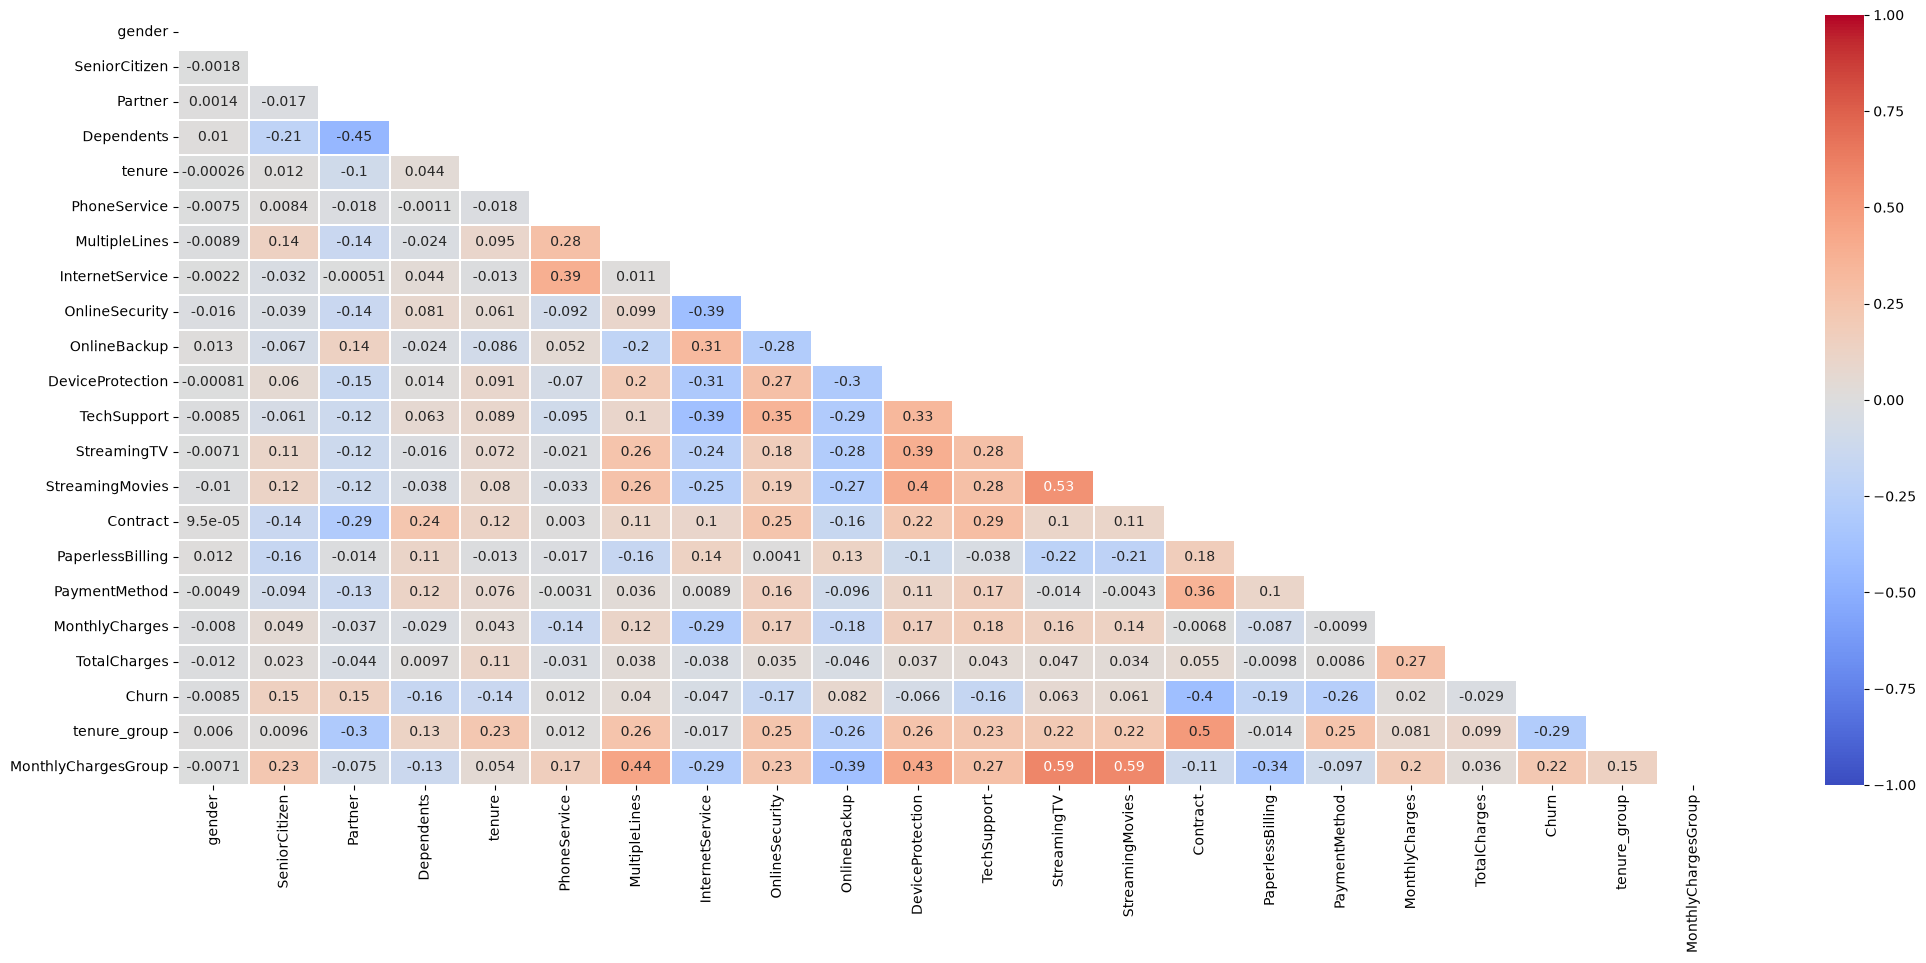

In [24]:
#製作數字欄位相關係數熱度圖
plt.figure(figsize=(25, 10))

corr = df.apply(lambda x: pd.factorize(x)[0]).corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

ax = sns.heatmap(corr, mask=mask, xticklabels=corr.columns, yticklabels=corr.columns, annot=True, linewidths=.2, cmap='coolwarm', vmin=-1, vmax=1)

In [25]:
numeric_df = df.select_dtypes(include="number")
corr = numeric_df.corr()
print(corr)

                SeniorCitizen    tenure  MonthlyCharges  TotalCharges
SeniorCitizen        1.000000  0.015683        0.219874      0.102411
tenure               0.015683  1.000000        0.246862      0.825880
MonthlyCharges       0.219874  0.246862        1.000000      0.651065
TotalCharges         0.102411  0.825880        0.651065      1.000000


In [26]:
#製作數字欄位相關係數熱度圖
# 取出數值欄位
numeric_df = df.select_dtypes(include="number")

# 計算相關係數
corr = numeric_df.corr()

# Heatmap
fig = px.imshow(
    corr,
    text_auto=".2f",
    aspect="auto",
    title="Correlation Heatmap"
)

fig.update_layout(
    xaxis_title="Variables",
    yaxis_title="Variables"
)

fig.show()

In [27]:
#類別欄位相關係數熱度圖
churn_heatmap = (
    df.pivot_table(
        index="Contract",
        columns="InternetService",
        values="Churn",
        aggfunc=lambda x: (x == "Yes").mean() * 100
    )
)

fig = px.imshow(
    churn_heatmap,
    text_auto=".1f",
    aspect="auto",
    color_continuous_scale="Reds",
    title="<b>Churn Rate by Contract and Internet Service</b>"
)

fig.update_layout(
    width=800,
    height=500,
    xaxis_title="Internet Service",
    yaxis_title="Contract"
)

fig.show()

##Machine Learning and Predictions

In [39]:
#載入機器學習套件
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
# from xgboost import XGBClassifier
# from catboost import CatBoostClassifier
from sklearn import metrics
from sklearn.metrics import roc_curve
from sklearn.metrics import recall_score, confusion_matrix, precision_score, f1_score, accuracy_score, classification_report, roc_auc_score

In [83]:
#Data Preprocessing
def str_to_int(dataframe_series):
    if dataframe_series.dtype=='str':
        dataframe_series = LabelEncoder().fit_transform(dataframe_series)
    return dataframe_series

In [ ]:
#str_to_int processing
df = df.apply(lambda x: str_to_int(x))
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,MonthlyChargesGroup
0,0,0,1,0,1,0,0,0,0,1,...,0,0,0,1,2,29.85,29.85,0,0-6,0-30
1,1,0,0,0,34,1,0,0,1,0,...,0,0,1,0,3,56.95,1889.50,0,25-36,50-70
2,1,0,0,0,2,1,0,0,1,1,...,0,0,0,1,3,53.85,108.15,1,0-6,50-70
3,1,0,0,0,45,0,0,0,1,0,...,0,0,1,0,0,42.30,1840.75,0,37-48,30-50
4,0,0,0,0,2,1,0,1,0,0,...,0,0,0,1,2,70.70,151.65,1,0-6,70-90


In [96]:
#確認dataframe的資料型態
df.dtypes

gender                    int64
SeniorCitizen             int64
Partner                   int64
Dependents                int64
tenure                    int64
PhoneService              int64
MultipleLines             int64
InternetService           int64
OnlineSecurity            int64
OnlineBackup              int64
DeviceProtection          int64
TechSupport               int64
StreamingTV               int64
StreamingMovies           int64
Contract                  int64
PaperlessBilling          int64
PaymentMethod             int64
MonthlyCharges          float64
TotalCharges            float64
Churn                     int64
tenure_group           category
MonthlyChargesGroup    category
dtype: object

In [86]:
#Machine Learning Model Evaluations and Predictions
# 1. 準備特徵 (X) 與目標變數 (y)
# 類別特徵需先經 One-Hot Encoding (pd.get_dummies) 轉為數值
X = df[['tenure', 'MonthlyCharges', 'TotalCharges']] 
y = df['Churn']

# 2. 切分訓練集與測試集 (80% 訓練 / 20% 測試，stratify 保持類別比例)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=40, stratify=y
)

# 3. 特徵標準化 (羅吉斯回歸對數值尺度敏感，強烈建議實施)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [87]:
#Logistic Regression
# 4. 建立與訓練模型 (class_weight='balanced' 自動調整不平衡資料權重)
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)

# 5. 進行預測 (預測類別與流失機率)
y_pred = lr_model.predict(X_test_scaled)
y_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

# 6. 模型表現評估
# print("=== 混淆矩陣 (Confusion Matrix) ===")
# print(confusion_matrix(y_test, y_pred))
accuracy_lr = lr_model.score(X_test_scaled, y_test)
print("Logistic Regression accuracy is :",accuracy_lr)

print("\n=== 分類報告 (Classification Report) ===")
print(classification_report(y_test, y_pred))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

Logistic Regression accuracy is : 0.7974413646055437

=== 分類報告 (Classification Report) ===
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1033
           1       0.67      0.46      0.55       374

    accuracy                           0.80      1407
   macro avg       0.75      0.69      0.71      1407
weighted avg       0.78      0.80      0.78      1407

ROC-AUC Score: 0.8324


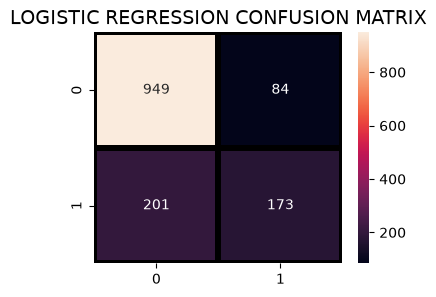

In [88]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred),
                annot=True,fmt = "d",linecolor="k",linewidths=3)
    
plt.title("LOGISTIC REGRESSION CONFUSION MATRIX",fontsize=14)
plt.show()

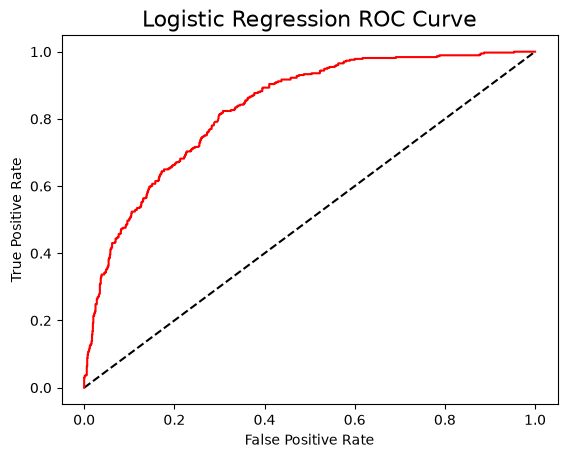

In [89]:
y_pred_prob = lr_model.predict_proba(X_test_scaled)[:,1]
# 計算 ROC 曲線所需的假陽性率 (FPR) 與真陽性率 (TPR)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.plot([0, 1], [0, 1], 'k--' )
plt.plot(fpr, tpr, label='Logistic Regression',color = "r")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression ROC Curve',fontsize=16)
plt.show();

In [90]:
#KNN
knn_model = KNeighborsClassifier(n_neighbors = 11) 
knn_model.fit(X_train,y_train)
predicted_y = knn_model.predict(X_test)
accuracy_knn = knn_model.score(X_test,y_test)
print("KNN accuracy:",accuracy_knn)

KNN accuracy: 0.7917555081734187


In [91]:
print("\n=== 分類報告 (Classification Report) ===")
print(classification_report(y_test, predicted_y))


=== 分類報告 (Classification Report) ===
              precision    recall  f1-score   support

           0       0.82      0.92      0.87      1033
           1       0.66      0.44      0.53       374

    accuracy                           0.79      1407
   macro avg       0.74      0.68      0.70      1407
weighted avg       0.78      0.79      0.78      1407



In [94]:
#SVC
svc_model = SVC(random_state = 1)
svc_model.fit(X_train,y_train)
predict_y = svc_model.predict(X_test)
accuracy_svc = svc_model.score(X_test,y_test)
print("SVM accuracy is :",accuracy_svc)

SVM accuracy is : 0.7341862117981521


In [71]:
print("\n=== 分類報告 (Classification Report) ===")
print(classification_report(y_test, y_pred))


=== 分類報告 (Classification Report) ===
              precision    recall  f1-score   support

          No       0.83      0.92      0.87      1033
         Yes       0.67      0.46      0.55       374

    accuracy                           0.80      1407
   macro avg       0.75      0.69      0.71      1407
weighted avg       0.78      0.80      0.78      1407



In [103]:
#Desion Tree CLassifier
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train,y_train)
predictdt_y = dt_model.predict(X_test)
accuracy_dt = dt_model.score(X_test,y_test)
print("Decision Tree accuracy is :",accuracy_dt)

Decision Tree accuracy is : 0.7292110874200426


In [104]:
print("\n=== 分類報告 (Classification Report) ===")
print(classification_report(y_test, predictdt_y))


=== 分類報告 (Classification Report) ===
              precision    recall  f1-score   support

           0       0.81      0.82      0.82      1033
           1       0.49      0.48      0.48       374

    accuracy                           0.73      1407
   macro avg       0.65      0.65      0.65      1407
weighted avg       0.73      0.73      0.73      1407



In [106]:
from sklearn.ensemble import VotingClassifier
clf1 = GradientBoostingClassifier()
clf2 = LogisticRegression()
clf3 = AdaBoostClassifier()
eclf1 = VotingClassifier(estimators=[('gbc', clf1), ('lr', clf2), ('abc', clf3)], voting='soft')
eclf1.fit(X_train, y_train)
predictions = eclf1.predict(X_test)
print("Final Accuracy Score ")
print(accuracy_score(y_test, predictions))

Final Accuracy Score 
0.7995735607675906


In [108]:
print("\n=== 分類報告 (Classification Report) ===")
print(classification_report(y_test, predictions))


=== 分類報告 (Classification Report) ===
              precision    recall  f1-score   support

           0       0.82      0.92      0.87      1033
           1       0.68      0.46      0.55       374

    accuracy                           0.80      1407
   macro avg       0.75      0.69      0.71      1407
weighted avg       0.79      0.80      0.79      1407



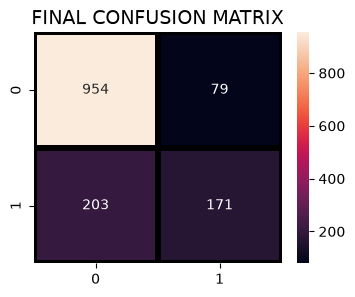

In [109]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, predictions),
                annot=True,fmt = "d",linecolor="k",linewidths=3)
    
plt.title("FINAL CONFUSION MATRIX",fontsize=14)
plt.show()

In [31]:
#匯出到Tableau 分析
# 存入當前目錄下的 data 資料夾
#df.to_excel('../data/processed/processed_customer_churn.xlsx', index=False)